# **Maestría en Inteligencia Artificial Aplicada**

## **Proyecto Integrador - TC5035**

## Semana 7: Avance 5 - Modelo final

### Profesores
- Dra. Grettel Barceló Alonso
- Dr. Luis Eduardo Falcón Morales

### Asesor
- Dr. Gerardo Jesús Camacho González

### Patrocinadores
- Dr. Jorge Antonio Ascencio Gutiérrez
- Yanmei King Loeza

### Equipo 29
- Carolina Lucas Dophe  –  A01702450
- Juan Pablo López Sánchez   –   A01313663
- Víctor Hugo Soto Herrera   –   A01706446

### Fecha de entrega
Domingo 1 de marzo de 2026

### Tabla de contenido
[Introducción](#intro)

1. [Carga de librerías y configuración inicial](#config)
2. [Preparación del entorno](#entorno)
3. [Definición del esquema de validación temporal](#esquema)
4. [Definición de métricas de evaluación](#metricas)
5. [Entrenamiento y evaluación de **modelos base**](#modelos)
   1. [Naïve Estacional](#5_1)
   2. [ARIMA](#5_2)
   3. [SARIMAX](#5_3)
   4. [SVR](#5_4)
   5. [GPR](#5_5)
   6. [MLP](#5_6)
   7. [LSTM](#5_7)
6. [Entrenamiento y evaluación de **modelos de ensamble**](#ensamble)
   1. [Promedio simple (Simple Averaging Ensemble)](#6_1)
   2. [Promedio ponderado (Weighted Average Ensemble)](#6_2)
   3. [Apilamiento con meta-modelo lineal (Stacking Ensemble con Ridge Regression)](#6_3)
   4. [Apilamiento con meta-modelo no lineal (Stacking Ensemble con Random Forest)](#6_4)
7. [Comparación global de modelos](#comparacion)
8. [Interpretación del modelo final](#interpretacion)

[Conclusiones](#conclusiones)

[Referencias](#ref)

### <a class="anchor" id="intro">Introducción</a>

Este notebook corresponde al **Avance 5 del proyecto**, cuyo objetivo es extender el análisis realizado en la etapa anterior mediante la construcción y evaluación de **modelos de ensamble** para la predicción de la producción de aguacate.

En el **Avance 4** se desarrolló un conjunto de modelos base de distinta naturaleza metodológica, incluyendo enfoques estadísticos y de aprendizaje automático: ARIMA, SARIMAX, SVR, GPR, MLP y LSTM, utilizando además un modelo **Naïve Estacional** como referencia para la métrica MASE. Los resultados mostraron que los modelos con mejor desempeño fueron **Gaussian Process Regression (GPR)** y **SARIMAX**, seguidos por **SVR** y **MLP**.

A partir de estos resultados, en esta etapa se explora la posibilidad de **mejorar la capacidad predictiva mediante técnicas de ensamble**, combinando la información de múltiples modelos para capturar distintos patrones presentes en la serie temporal.

#### **Objetivo de esta entrega**

Los objetivos principales de este notebook son:

* Construir **modelos de ensamble homogéneos y heterogéneos** utilizando los modelos base desarrollados previamente.
* Evaluar el desempeño de estos modelos utilizando las métricas definidas en la etapa anterior.
* Comparar los modelos de ensamble con los modelos individuales.
* Seleccionar el **modelo final** considerando tanto el desempeño predictivo como la coherencia con el problema de negocio.

#### **Nota sobre reutilización del código**

Las secciones iniciales de este notebook reutilizan la estructura y la mayoría del código desarrollado en el **Avance 4**, incluyendo la preparación de datos, el esquema de validación temporal, la definición de métricas y el entrenamiento de los modelos base.

Dado que estas etapas forman parte del **pipeline fundamental del problema de predicción**, se mantienen prácticamente sin modificaciones, aplicando únicamente **ajustes menores de refactorización** cuando es necesario para facilitar su integración con los modelos de ensamble desarrollados en esta etapa.

Para una descripción detallada de estas etapas metodológicas, se recomienda consultar el notebook correspondiente al **Avance 4**.

### <a class="anchor" id="config">1. Carga de librerías y configuración inicial</a>

En esta sección se cargan las librerías necesarias para la implementación de los distintos modelos, el cálculo de métricas y la visualización de resultados. Asimismo, se establecen configuraciones iniciales orientadas a garantizar reproducibilidad y claridad en el análisis.

In [1]:
# Librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import time

# Modelos clásicos de series de tiempo
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelos de Machine Learning
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, DotProduct,
    ConstantKernel, WhiteKernel
)

# Modelos de ensamble
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

# Modelo LSTM (Deep Learning)
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Gráficas de diagnóstico
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

2026-02-25 23:06:24.243115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Configuración general
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

warnings.filterwarnings('ignore')

In [3]:
# Definición de rutas base
DATA_DIR = Path("data")
PROCESSED_DATA_DIR = DATA_DIR / "processed"

### <a class="anchor" id="entorno">2. Preparación del entorno</a>

En esta sección se cargan las librerías necesarias y se realiza la lectura del conjunto de datos correspondiente a la serie temporal de producción de aguacate. Asimismo, se verifica la estructura del dataset, el formato de las variables y la correcta interpretación de la variable temporal, con el fin de asegurar la consistencia del análisis posterior.

#### 2.1 Carga de datos procesados

In [4]:
# Cargar datos procesados
X = pd.read_csv(PROCESSED_DATA_DIR / "X_final_mensual.csv")
y = pd.read_csv(PROCESSED_DATA_DIR / "y_mensual.csv")

# Convertir Fecha a datetime
X['Fecha'] = pd.to_datetime(X['Fecha'])
y['Fecha'] = pd.to_datetime(y['Fecha'])

# Asignar Fecha como índice
X = X.set_index('Fecha')
y = y.set_index('Fecha')

# Ordenar por fecha
X = X.sort_index()
y = y.sort_index()

# Extraer la variable objetivo
y = y.iloc[:, 0]  # Volumenproduccion

print("Datos cargados exitosamente")
print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

Datos cargados exitosamente

Forma de X: (345, 6)
Forma de y: (345,)


#### 2.2 Verificación estructural

In [5]:
# Verificar alineación X-y
assert (X.index == y.index).all(), "Los índices de X e y no coinciden"

# Mostrar rango temporal
print(f"Rango temporal: {X.index.min()} a {X.index.max()}")
print(f"Número de observaciones: {len(X)}")
print(f"\nDimensiones:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")

# Verificar valores faltantes
print(f"\nValores faltantes en X: {X.isnull().sum().sum()}")
print(f"Valores faltantes en y: {y.isnull().sum()}")

# Primeras y últimas filas
print(f"\nPrimeras observaciones:")
print(X.head(5))
print(f"\nÚltimas observaciones:")
print(X.tail(5))

Rango temporal: 1996-01-01 00:00:00 a 2024-12-01 00:00:00
Número de observaciones: 345

Dimensiones:
  X: (345, 6)
  y: (345,)

Valores faltantes en X: 0
Valores faltantes en y: 0

Primeras observaciones:
            Anio  Sembrada  Cosechada  Rendimiento   Mes_Sin   Mes_Cos
Fecha                                                                 
1996-01-01   0.0  0.170385   0.093448     0.828413  0.750000  0.933013
1996-02-01   0.0  0.170385   0.093448     0.828413  0.933013  0.750000
1996-03-01   0.0  0.170385   0.093448     0.828413  1.000000  0.500000
1996-04-01   0.0  0.170385   0.093448     0.828413  0.933013  0.250000
1996-05-01   0.0  0.170385   0.093448     0.828413  0.750000  0.066987

Últimas observaciones:
            Anio  Sembrada  Cosechada  Rendimiento   Mes_Sin   Mes_Cos
Fecha                                                                 
2024-08-01   1.0   0.55001    0.68664     0.100455  0.066987  0.250000
2024-09-01   1.0   0.55001    0.68664     0.100455  0.000000 

### <a class="anchor" id="esquema">3. Definición del esquema de validación temporal</a>

Dado que el problema corresponde a una **serie temporal**, se emplea un esquema de partición que respeta el orden cronológico de los datos. Esto permite evitar fuga de información (*data leakage*) entre entrenamiento y prueba, asegurando que los modelos sean evaluados en condiciones consistentes con un escenario de predicción real.

#### 3.1 Split fijo (80/20)

Se implementa una partición cronológica donde el 80% inicial de las observaciones se destina al entrenamiento y el 20% final se reserva para evaluación.

In [6]:
# Definir el punto de split (80% entrenamiento, 20% prueba)
split_idx = int(len(X) * 0.8)
train_date = X.index[split_idx]

# Crear subconjuntos
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Split realizado en: {train_date}")
print(f"\nConjunto de entrenamiento:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  Período: {X_train.index.min()} a {X_train.index.max()}")

print(f"\nConjunto de prueba:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
print(f"  Período: {X_test.index.min()} a {X_test.index.max()}")

Split realizado en: 2019-01-01 00:00:00

Conjunto de entrenamiento:
  X_train: (276, 6)
  y_train: (276,)
  Período: 1996-01-01 00:00:00 a 2018-12-01 00:00:00

Conjunto de prueba:
  X_test: (69, 6)
  y_test: (69,)
  Período: 2019-01-01 00:00:00 a 2024-12-01 00:00:00


#### 3.2 Exportación de conjuntos de datos

Con el fin de mantener consistencia y trazabilidad entre avances, los subconjuntos de entrenamiento y prueba se exportan nuevamente al directorio `data/processed`.

In [7]:
# Exportar subconjuntos a data/processed
X_train.to_csv(PROCESSED_DATA_DIR / "X_train_temporal.csv")
X_test.to_csv(PROCESSED_DATA_DIR / "X_test_temporal.csv")
y_train.to_csv(PROCESSED_DATA_DIR / "y_train_temporal.csv", header=True, index=True)
y_test.to_csv(PROCESSED_DATA_DIR / "y_test_temporal.csv", header=True, index=True)

print("Subconjuntos exportados.")

Subconjuntos exportados.


### <a class="anchor" id="metricas">4. Definición de métricas de evaluación</a>

Para evaluar el desempeño de los modelos se utilizan diversas métricas de error, incluyendo **MAE, RMSE, MAPE y MASE**. La métrica MASE se calcula utilizando como referencia un modelo **Naïve Estacional**, lo que permite interpretar el desempeño de los modelos en relación con un baseline sencillo pero representativo para series temporales.

#### 4.1 Métricas utilizadas

Las siguientes métricas se definen **antes** de entrenar los modelos, para evitar sesgo en la selección:

1. **MAE (Mean Absolute Error)**
   - Fórmula: $\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$
   - Ventaja: Interpretable directamente en unidades originales
   - Uso: Evaluación práctica del error esperado

2. **RMSE (Root Mean Squared Error)**
   - Fórmula: $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$
   - Ventaja: Penaliza errores grandes más severamente
   - Uso: Comparación entre modelos (sensible a outliers)

3. **MAPE (Mean Absolute Percentage Error)**
   - Fórmula: $\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100$
   - Ventaja: Independiente de escala, útil en contexto productivo
   - Uso: Evaluación de precisión relativa

4. **R² (Coeficiente de determinación)**
   - Fórmula: $R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$
   - Ventaja: Métrica complementaria para evaluar capacidad explicativa
   - Uso: Proporción de varianza explicada

5. **MASE (Mean Absolute Scaled Error)**
   - Fórmula: $MASE = \frac{MAE_{modelo(TEST)}}{MAE_{naïve(TRAIN)}}$
   - El denominador se calcula exclusivamente sobre el conjunto de entrenamiento utilizando un modelo naïve estacional, garantizando que la evaluación en test no incorpore información futura.
   - Escala el error absoluto del modelo respecto al error de un modelo ingenuo de referencia.
   - Ventaja: Permite comparación justa entre modelos y evita problemas de escala.
   - Uso: Benchmarking contra un baseline temporal (naïve estacional en este caso).
   - Interpretación:
     - MASE < 1: Mejor que el baseline
     - MASE = 1: Igual al baseline
     - MASE > 1: Peor que el baseline

In [8]:
# Cálculo del denominador MASE
# Naïve estacional (lag=12 para mensual)
seasonality = 12

naive_train = y_train.shift(seasonality)
naive_train = naive_train.dropna()

mase_denom = mean_absolute_error(
    y_train[seasonality:],
    naive_train
)

print(f"Denominador MASE (train naive estacional): {mase_denom:.4f}")

Denominador MASE (train naive estacional): 0.0866


In [9]:
# Función para calcular métricas de evaluación
def calculate_metrics(y_true, y_pred, mase_denom, model_name="Model"):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)

    mape = np.nanmean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
    ) * 100

    r2 = r2_score(y_true, y_pred)

    mase = mae / mase_denom if mase_denom != 0 else np.inf

    return {
        'Modelo': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2,
        'MASE': mase
    }


# Función para diagnóstico de residuos
def residuals_diagnostic(y_true, y_pred, lags=20, titulo="Modelo"):

    # Convertir a array si vienen como Series
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    residuals = y_true - y_pred

    print(f"\n--- Diagnóstico de Residuos: {titulo} ---")
    print(f"Media residuos: {np.mean(residuals):.6f}")
    print(f"Varianza residuos: {np.var(residuals):.6f}")

    # Test Ljung-Box
    lb_test = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    print("\nLjung-Box p-value:", lb_test["lb_pvalue"].values[0])

    # Gráficas de diagnóstico
    fig, axs = plt.subplots(2, 2, figsize=(12,8))

    # 1. Serie temporal residuos
    axs[0,0].plot(residuals)
    axs[0,0].axhline(0, linestyle="--")
    axs[0,0].set_title("Residuos en el tiempo")

    # 2. Histograma + densidad
    sns.histplot(residuals, kde=True, ax=axs[0,1])
    axs[0,1].set_title("Distribución de residuos")

    # 3. ACF
    plot_acf(residuals, lags=lags, ax=axs[1,0])

    # 4. Residuos vs predicción (para homocedasticidad)
    axs[1,1].scatter(y_pred, residuals)
    axs[1,1].axhline(0, linestyle="--")
    axs[1,1].set_title("Residuos vs Predicción")

    plt.tight_layout()
    plt.show()

    return residuals

In [10]:
# Lista para almacenar resultados de todos los modelos
resultados_modelos = []
modelos_entrenados = {}

# Contenedor para los mejores dos modelos
resultados_modelos_top2 = []
modelos_entrenados_top2 = {}

print("Contenedor de resultados inicializado")

Contenedor de resultados inicializado


### <a class="anchor" id="modelos">5. Entrenamiento y evaluación de **modelos base**</a>

En esta sección se entrenan los modelos individuales considerados en la etapa anterior: **ARIMA, SARIMAX, SVR, GPR, MLP y LSTM**. Cada modelo se ajusta utilizando el conjunto de entrenamiento y posteriormente se generan predicciones sobre el conjunto de prueba, las cuales se utilizan para calcular las métricas de desempeño correspondientes.

Los resultados obtenidos en esta etapa permiten identificar los modelos con mejor desempeño, que posteriormente serán utilizados como componentes en las estrategias de **ensamble** desarrolladas en las secciones siguientes.

> **`IMPORTANTE`**: Aunque todos los modelos base desarrollados en el Avance 4 se mantienen en el notebook para efectos de comparación, la construcción de los modelos de ensamble se realiza únicamente utilizando aquellos que demostraron mayor capacidad predictiva. En particular, los modelos **GPR**, **SARIMAX**, **SVR** y **MLP** mostraron un desempeño significativamente superior al modelo Naïve Estacional.
> 
> Por el contrario, **ARIMA** y **LSTM presentaron resultados cercanos al baseline**, lo que sugiere una capacidad limitada para capturar patrones adicionales en la serie. Incluir modelos con bajo desempeño en un ensamble puede introducir ruido en las predicciones agregadas, por lo que estos modelos se conservan únicamente como referencia en la comparación final.

#### <a class="anchor" id="5_1">5.1 Modelo de Referencia: Naïve Estacional</a>

El modelo Naïve Estacional constituye el punto de referencia mínimo esperado para una serie temporal mensual con estacionalidad anual. La predicción para cada período del conjunto de prueba corresponde al valor observado en el mismo mes del año anterior (rezago de 12 meses).

In [11]:
tiempo_inicial = time.perf_counter()

# Modelo Naïve Estacional (referencia, lag = 12 meses)
# Predicción: valor del mismo mes del año anterior
lag_seasonal = 12

# Predicción usando shift sobre la serie completa
y_naive_full = y.shift(lag_seasonal)

# Extraer únicamente la parte correspondiente al test
y_naive = y_naive_full.loc[y_test.index].values

tiempo_entrenamiento = time.perf_counter() - tiempo_inicial
print(f"Tiempo de entrenamiento Naïve Estacional: {tiempo_entrenamiento:.2f} segundos")

Tiempo de entrenamiento Naïve Estacional: 0.00 segundos


In [12]:
# Calcular métricas
metrics_naive = calculate_metrics(
    y_test,
    y_naive,
    mase_denom,
    model_name="Naïve Estacional"
)
metrics_naive["Tiempo_Entrenamiento"] = tiempo_entrenamiento

# Almacenar para comparación
resultados_modelos.append(metrics_naive)

modelos_entrenados['Naive_Estacional'] = {
    'modelo': None,
    'y_pred': y_naive
}

metrics_naive

{'Modelo': 'Naïve Estacional',
 'MAE': 0.08938220801642596,
 'RMSE': 0.11066893889876882,
 'MAPE': 12.996778511639798,
 'R²': -0.2500603650896023,
 'MASE': 1.0321084369659865,
 'Tiempo_Entrenamiento': 0.0027498258277773857}

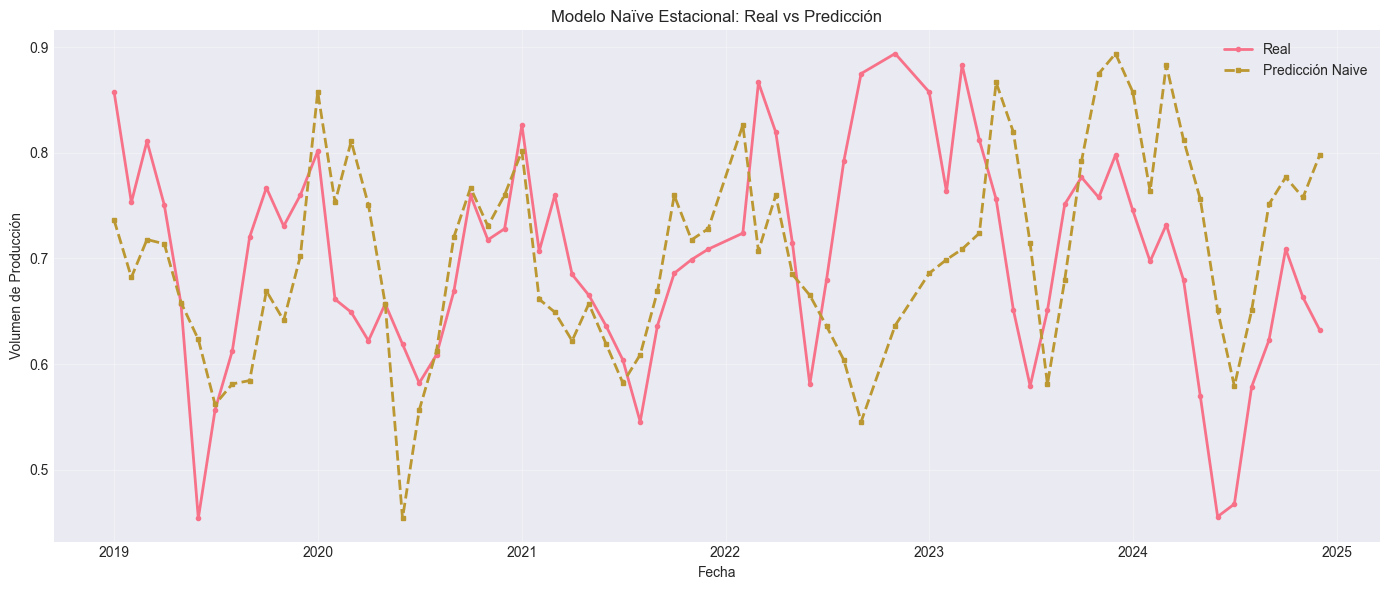

In [13]:
# Visualización: Modelo Naïve Estacional
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(y_test.index, y_naive, label='Predicción Naive', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Modelo Naïve Estacional: Real vs Predicción')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### <a class="anchor" id="5_2">5.2 ARIMA</a>

**Descripción:** El modelo **ARIMA (AutoRegressive Integrated Moving Average)** es un enfoque estadístico clásico para series de tiempo univariadas que modela la dependencia temporal a través de tres componentes: autoregresivo (AR), diferenciación (I) y promedio móvil (MA).

In [14]:
# Realizar prueba ADF
adf_test = adfuller(y_train)
print("ADF test p-value: ", adf_test[1])

ADF test p-value:  0.799413628648084


<Axes: xlabel='Fecha'>

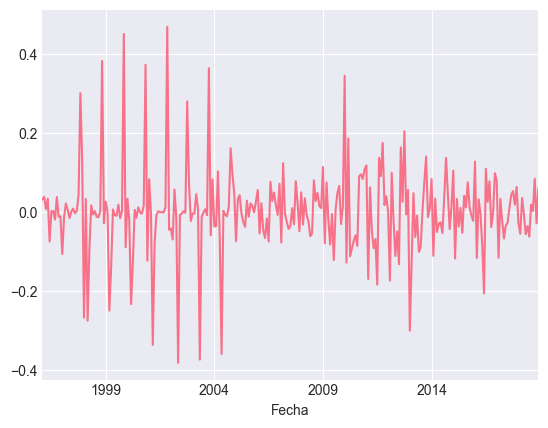

In [15]:
# Aplicar diferenciación
y_train_diff = y_train.diff().dropna()
y_train_diff.plot()

In [16]:
# Comprobar estacionalidad
adf_test = adfuller(y_train_diff)
print("ADF test p-value: ", adf_test[1])

ADF test p-value:  3.7153767815361987e-08


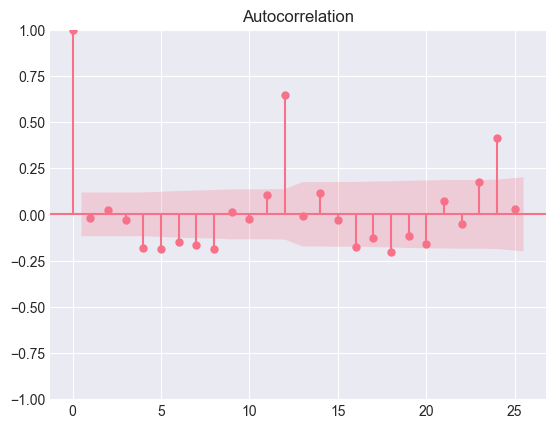

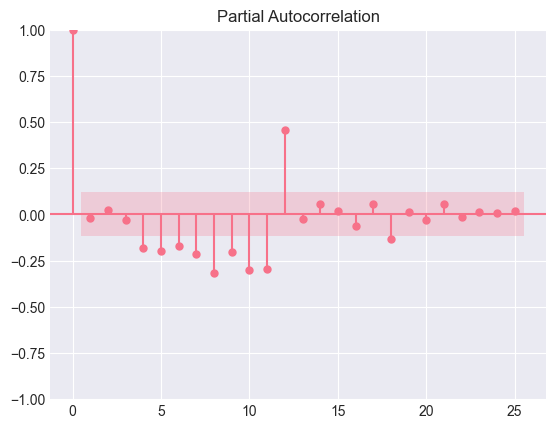

In [17]:
# Graficar ACF y PACF del dataset estacional
plot_acf(y_train_diff)
plot_pacf(y_train_diff)
plt.show()

In [18]:
# Entrenamiento del modelo ARIMA
arima_model = ARIMA(y_train, order = (50,1,50))

tiempo_inicial = time.time()
arima_model = arima_model.fit()
tiempo_entrenamiento = time.time() - tiempo_inicial

# Despliegue de métricas predefinidas por la librería
print(arima_model.summary())
print(f"\nTiempo de entrenamiento ARIMA: {tiempo_entrenamiento:.2f} segundos")

                               SARIMAX Results                                
Dep. Variable:      Volumenproduccion   No. Observations:                  276
Model:               ARIMA(50, 1, 50)   Log Likelihood                 353.331
Date:                Wed, 25 Feb 2026   AIC                           -504.661
Time:                        23:08:24   BIC                           -139.367
Sample:                    01-01-1996   HQIC                          -358.058
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0485     50.850      0.001      0.999     -99.615      99.712
ar.L2          0.0817     30.253      0.003      0.998     -59.214      59.377
ar.L3         -0.1009     18.038     -0.006      0.9

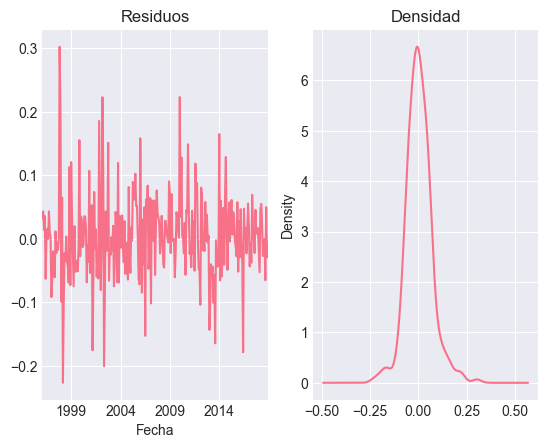

In [19]:
# Se obtienen los residuos
residuos = arima_model.resid[1:]

# Se grafican los residuos y la densidad
fig, ax = plt.subplots(1,2)
residuos.plot(title = "Residuos", ax = ax[0])
residuos.plot(title = "Densidad", ax = ax[1], kind = 'kde')
plt.show()

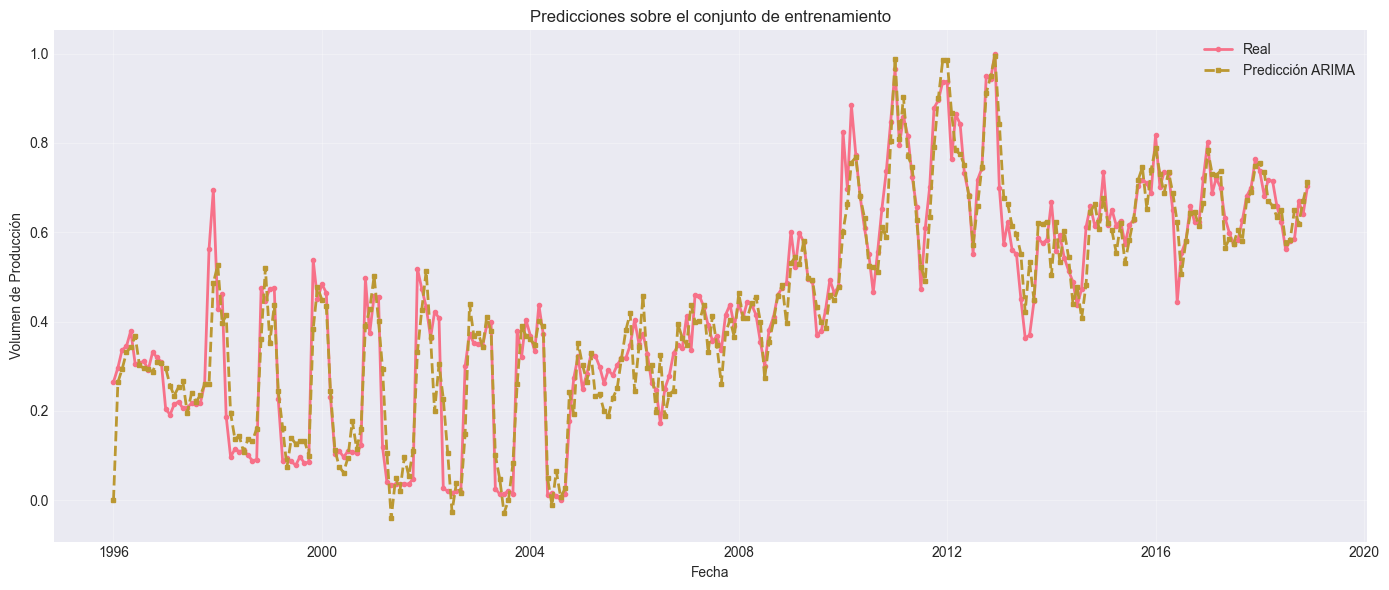

In [20]:
# Comparación gráfica entre el modelo entrenado y los datos reales sobre el conjunto de entrenamiento
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_train, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(arima_model.fittedvalues, label='Predicción ARIMA', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Predicciones sobre el conjunto de entrenamiento')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

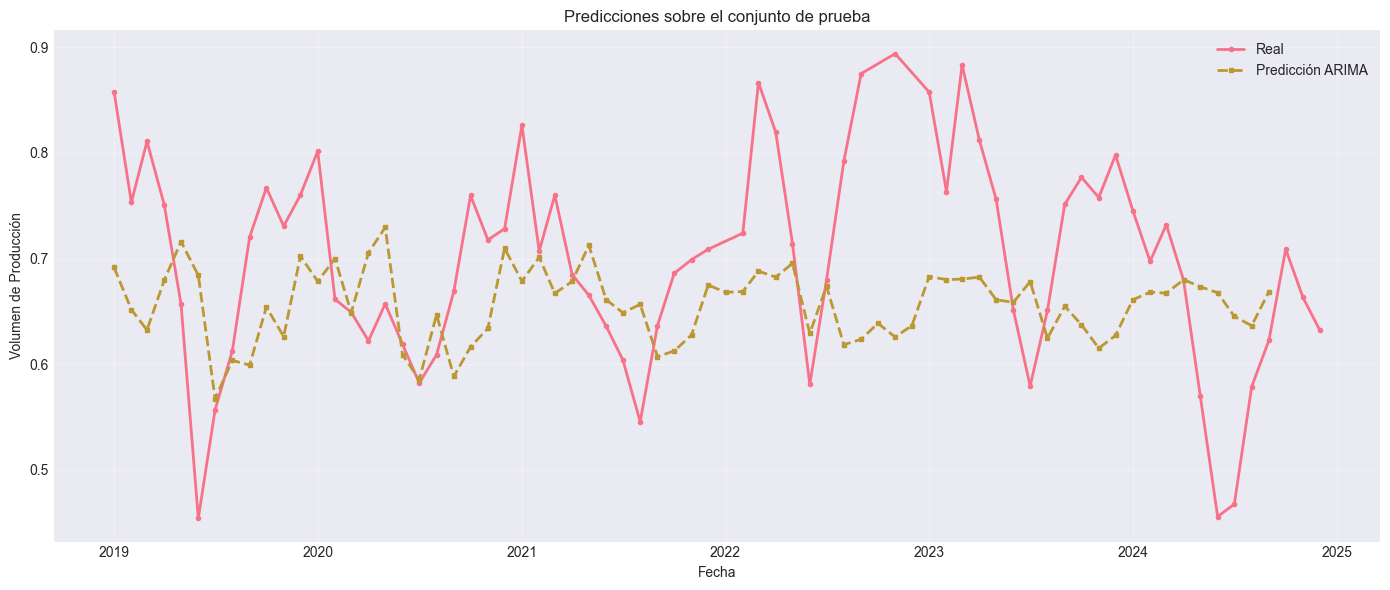

In [21]:
# Realizar predicciones
forecast = arima_model.forecast(steps = len(y_test))

# Comparación gráfica entre el modelo entrenado y los datos reales sobre el conjunto de prueba
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(forecast, label='Predicción ARIMA', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Predicciones sobre el conjunto de prueba')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Entrenamiento del modelo ARIMA de forma automática
auto_arima_model = pm.auto_arima(y_train, stepwise = False, seasonal = False)
auto_arima_model.order

(4, 1, 1)

In [23]:
# Despliegue de métricas predefinidas por la librería
auto_arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  276
Model:               SARIMAX(4, 1, 1)   Log Likelihood                 255.381
Date:                Wed, 25 Feb 2026   AIC                           -496.761
Time:                        23:08:31   BIC                           -471.444
Sample:                    01-01-1996   HQIC                          -486.601
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0008      0.001      1.099      0.272      -0.001       0.002
ar.L1          0.6800      0.076      9.001      0.000       0.532       0.828
ar.L2          0.0395      0.094      0.421      0.674      -0.145       0.224
ar.L3         -0.0492      0.096     -0.510      0.610      -0.238       0.140
ar.L4         -0.2546      0.082     -3.121      0.002      -0.414      -0.095
ma.L1         -0.8818      0.042    -20.972      0.000      -0.964      -0.799
sigma2         0.0091      0.001     14.976      0.000       0.008       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.43   Jarque-Bera (JB):               170.01
Prob(Q):                              0.51   Prob(JB):                         0.00
Heteroskedasticity (H):               0.46   Skew:                             0.58
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

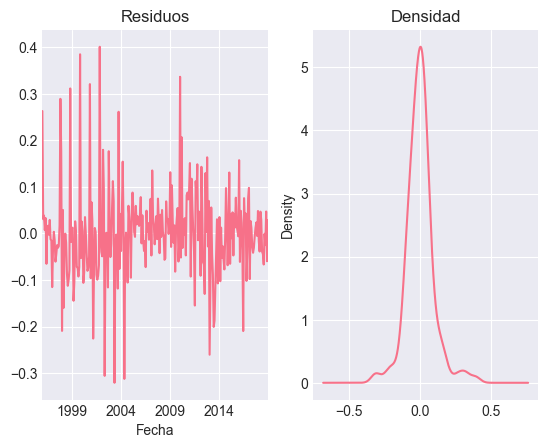

In [24]:
# Se obtienen los residuos
auto_residuos = auto_arima_model.resid()

# Se grafican los residuos y la densidad
fig, ax = plt.subplots(1,2)
auto_residuos.plot(title = "Residuos", ax = ax[0])
auto_residuos.plot(title = "Densidad", ax = ax[1], kind = 'kde')
plt.show()

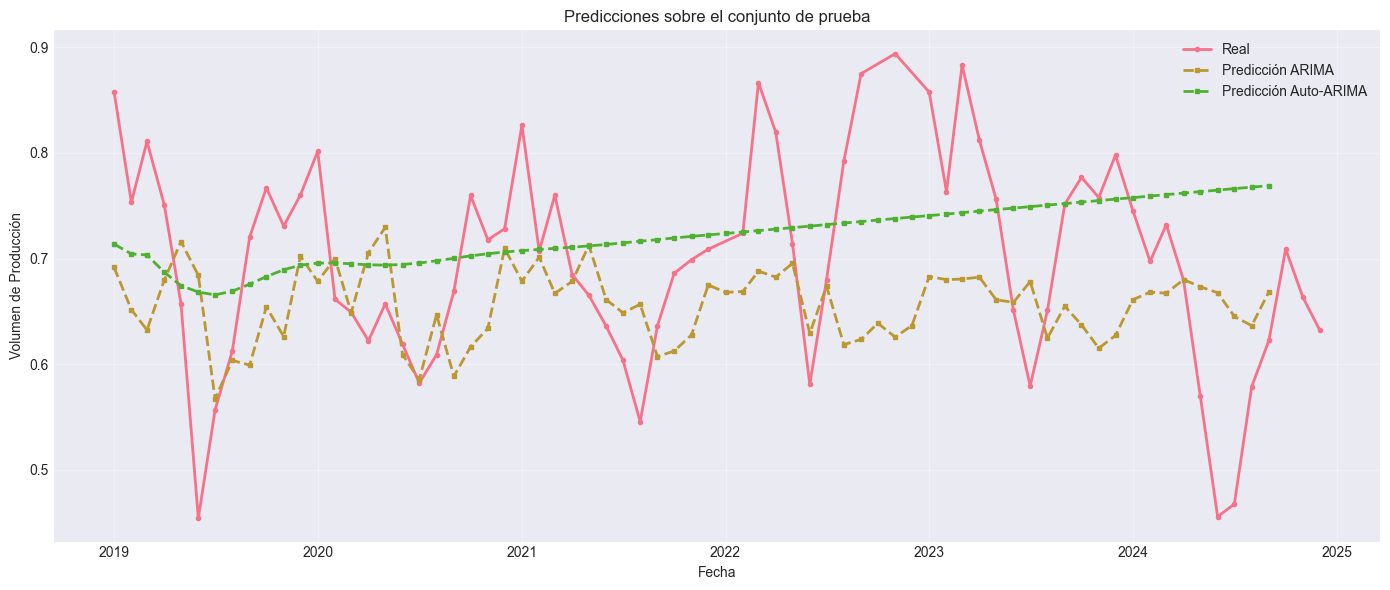

In [25]:
# Realizar predicciones
auto_forecast = auto_arima_model.predict(n_periods = len(y_test))

# Comparación gráfica entre el modelo entrenado manualmente, automático y los datos reales sobre el conjunto de prueba
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(forecast, label='Predicción ARIMA', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.plot(auto_forecast, label='Predicción Auto-ARIMA', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Predicciones sobre el conjunto de prueba')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Alineación de índices, que por algún motivo podrían estar desalineados
common_index = y_test.index.intersection(forecast.index)

y_true = y_test.loc[common_index]
y_pred = forecast.loc[common_index]

arima_model_metrics = calculate_metrics(
    y_true=y_true,
    y_pred=y_pred,
    mase_denom=mase_denom,
    model_name="ARIMA"
)

# Calcular métricas de desempeño para el modelo ARIMA
arima_model_metrics = calculate_metrics(y_true = y_test, y_pred = forecast, mase_denom = mase_denom, model_name = "ARIMA")
arima_model_metrics["Tiempo_Entrenamiento"] = tiempo_entrenamiento

# Almacenar para comparación
resultados_modelos.append(arima_model_metrics)

modelos_entrenados['ARIMA'] = {
    'modelo': arima_model,
    'y_pred': forecast
}

arima_model_metrics

{'Modelo': 'ARIMA',
 'MAE': 0.09212861089022673,
 'RMSE': 0.11372976643624746,
 'MAPE': 13.198084459259796,
 'R²': -0.32016370356369395,
 'MASE': 1.0638215221566822,
 'Tiempo_Entrenamiento': 113.2992000579834}

In [27]:
# Calcular métricas de desempeño para el modelo auto-ARIMA
auto_arima_model_metrics = calculate_metrics(y_true = y_test, y_pred = auto_forecast, mase_denom = mase_denom, model_name = "Auto-ARIMA")
auto_arima_model_metrics["Tiempo_Entrenamiento"] = tiempo_entrenamiento

# Almacenar para comparación
resultados_modelos.append(auto_arima_model_metrics)

modelos_entrenados['Auto_ARIMA'] = {
    'modelo': auto_arima_model,
    'y_pred': auto_forecast
}

auto_arima_model_metrics

{'Modelo': 'Auto-ARIMA',
 'MAE': 0.08190900815146984,
 'RMSE': 0.10410365156976291,
 'MAPE': 12.785916981516115,
 'R²': -0.10614336863442375,
 'MASE': 0.9458143880391933,
 'Tiempo_Entrenamiento': 113.2992000579834}

#### <a class="anchor" id="5_3">5.3 SARIMAX</a>

**Descripción:** El modelo **SARIMAX (Seasonal ARIMA with eXogenous variables)** extiende ARIMA al incorporar componentes estacionales explícitos y la posibilidad de incluir variables exógenas. En series mensuales con estacionalidad anual, el componente estacional permite modelar dependencias con rezagos de 12 períodos, mientras que las variables explicativas (`X_train`) pueden capturar efectos estructurales adicionales.

In [28]:
# Entrenar modelo SARIMAX y obtener los mejores hiperparámetros
tiempo_inicial = time.time()
sarimax_model = pm.auto_arima(y = y_train, X = X_train, m = 12)
tiempo_entrenamiento = time.time() - tiempo_inicial

print(f"Tiempo de entrenamiento SARIMAX: {tiempo_entrenamiento:.2f} segundos")

Tiempo de entrenamiento SARIMAX: 22.38 segundos


In [29]:
# Mejores hiperparámetros
sarimax_model.order

(1, 0, 0)

In [30]:
# Despliegue de métricas predefinidas por la librería
sarimax_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  276
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                 359.281
Date:                            Wed, 25 Feb 2026   AIC                           -698.561
Time:                                    23:08:54   BIC                           -662.357
Sample:                                01-01-1996   HQIC                          -684.033
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept      -0.0191      0.013     -1.487      0.137      -0.044       0.006
Anio            0.2138      0.129      1.663      0.096      -0.038       0.466
Sembrada       -0.1156      0.137     -0.842      0.400      -0.385       0.154
Cosechada       0.6750      0.155      4.363      0.000       0.372       0.978
Rendimiento     0.1674      0.059      2.843      0.004       0.052       0.283
Mes_Sin         0.1032      0.051      2.041      0.041       0.004       0.202
Mes_Cos         0.1948      0.050      3.923      0.000       0.097       0.292
ar.L1           0.5624      0.041     13.824      0.000       0.483       0.642
ar.S.L12        0.5872      0.035     16.666      0.000       0.518       0.656
sigma2          0.0042      0.000     13.458      0.000       0.004       0.005
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                79.72
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               0.32   Skew:                             0.58
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

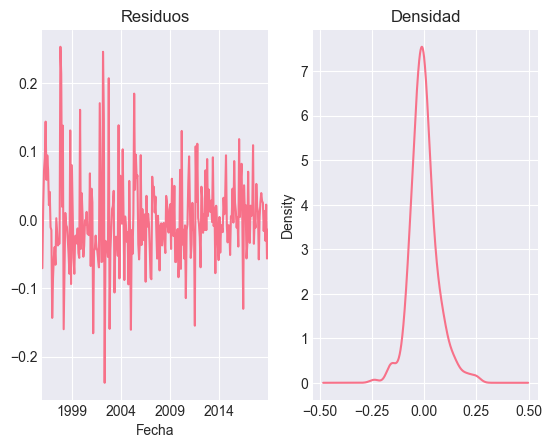

In [31]:
# Se obtienen los residuos
sarimax_residuos = sarimax_model.resid()

# Se grafican los residuos y la densidad
fig, ax = plt.subplots(1,2)
sarimax_residuos.plot(title = "Residuos", ax = ax[0])
sarimax_residuos.plot(title = "Densidad", ax = ax[1], kind = 'kde')
plt.show()

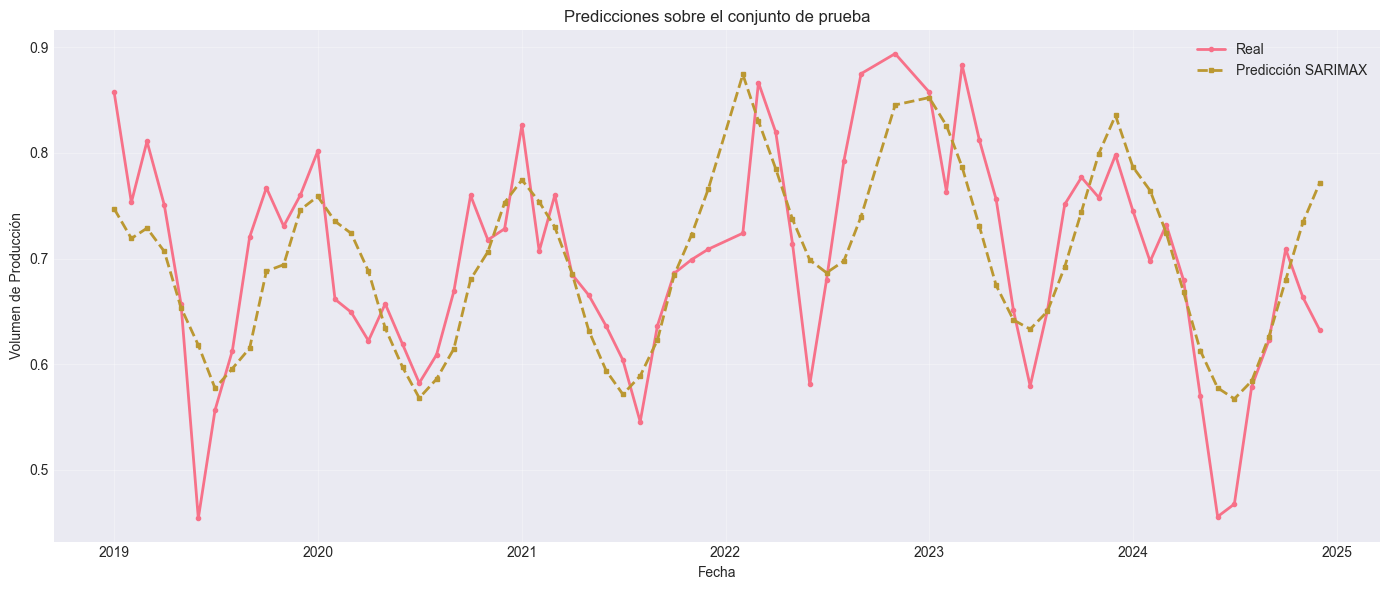

In [32]:
# Realizar predicciones
sarimax_forecast = pd.Series(sarimax_model.predict(n_periods = len(y_test), X = X_test))
sarimax_forecast.index = y_test.index

# Comparación gráfica entre el modelo entrenado y los datos reales sobre el conjunto de prueba
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(sarimax_forecast, label='Predicción SARIMAX', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Predicciones sobre el conjunto de prueba')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Calcular métricas de desempeño para el modelo SARIMAX
sarimax_model_metrics = calculate_metrics(y_true = y_test, y_pred = sarimax_forecast, mase_denom = mase_denom, model_name = "SARIMAX")
sarimax_model_metrics["Tiempo_Entrenamiento"] = tiempo_entrenamiento

# Almacenar para comparación
resultados_modelos.append(sarimax_model_metrics)

modelos_entrenados['SARIMAX'] = {
    'modelo': sarimax_model,
    'y_pred': sarimax_forecast
}

sarimax_model_metrics

{'Modelo': 'SARIMAX',
 'MAE': 0.04993936552064398,
 'RMSE': 0.06346030130144356,
 'MAPE': 7.411434398055623,
 'R²': 0.588960315921909,
 'MASE': 0.5766566035279952,
 'Tiempo_Entrenamiento': 22.38457489013672}

#### <a class="anchor" id="5_4">5.4 SVR</a>

**Descripción:** El modelo **Support Vector Regression (SVR)** es una extensión de las Máquinas de Vectores de Soporte al problema de regresión. Su objetivo es encontrar una función que minimice el error dentro de un margen tolerado, manteniendo simultáneamente la máxima generalización.

In [34]:
# Definir modelo inicial
svr_model_init = SVR(
                    kernel='rbf', 
                    C=1,         
                    epsilon=0.1,  
                    gamma= 'scale'  
                  )

# Entrenamiento
svr_model_init.fit(X_train, y_train)

# Predicción
y_svr_init = svr_model_init.predict(X_test)

In [35]:
# Calcular métricas
metrics_svr_init = calculate_metrics(
                                    y_test,
                                    y_svr_init,
                                    mase_denom,
                                    model_name="SVR"
                                  )

metrics_svr_init

{'Modelo': 'SVR',
 'MAE': 0.07666184833501231,
 'RMSE': 0.09391543040453129,
 'MAPE': 10.749290777399269,
 'R²': 0.099770169242001,
 'MASE': 0.8852247244265035}

In [36]:
# Definir modelo
svr_model = SVR(
                kernel='rbf',
                C=100,
                epsilon=0.01,
                gamma= 0.001
               )

# Entrenamiento
tiempo_inicial = time.time()
svr_model.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - tiempo_inicial

print(f"Tiempo de entrenamiento SVR: {tiempo_entrenamiento:.2f} segundos")

# Predicción
y_svr = svr_model.predict(X_test)

Tiempo de entrenamiento SVR: 0.01 segundos


In [37]:
# Calcular métricas
metrics_svr = calculate_metrics(
                                y_test,
                                y_svr,
                                mase_denom,
                                model_name="SVR"
                               )
metrics_svr["Tiempo_Entrenamiento"] = tiempo_entrenamiento


# Almacenar para comparación
resultados_modelos.append(metrics_svr)

modelos_entrenados['SVR'] = {
                            'modelo': svr_model,
                            'y_pred': y_svr
                            }
metrics_svr

{'Modelo': 'SVR',
 'MAE': 0.055631417404423414,
 'RMSE': 0.0670412369652287,
 'MAPE': 8.099991402983221,
 'R²': 0.5412632523466543,
 'MASE': 0.642383495974166,
 'Tiempo_Entrenamiento': 0.01152801513671875}

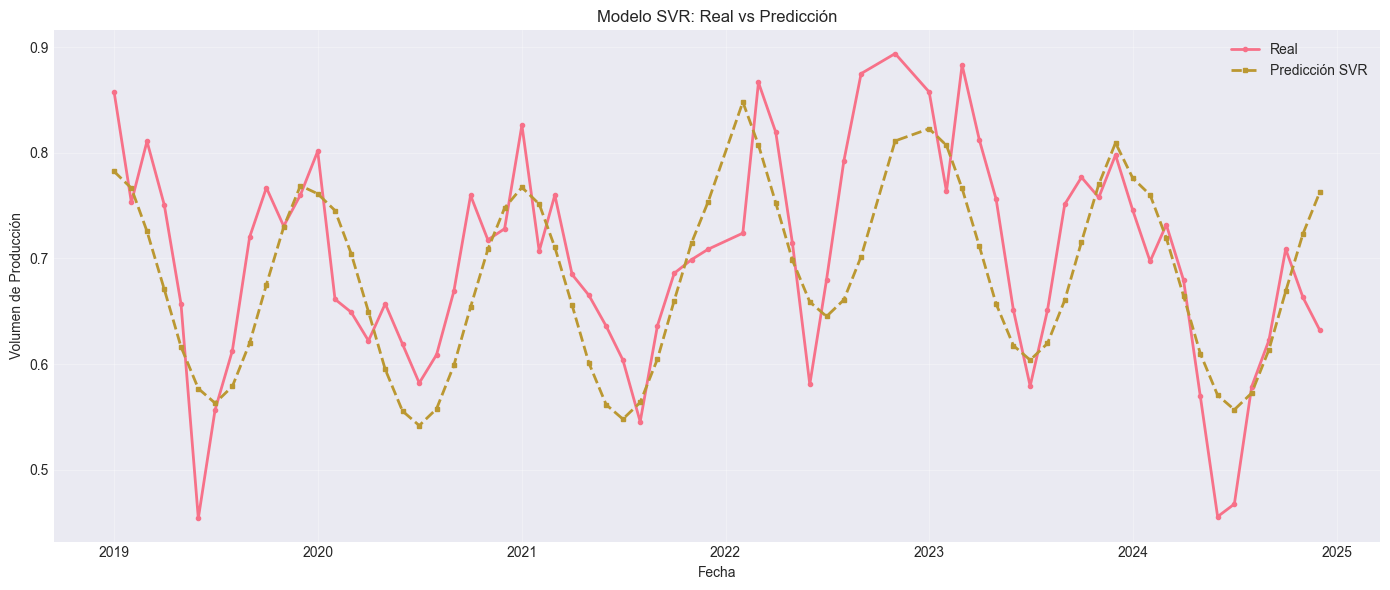

In [38]:
# Visualización: Modelo SVR Predicciones sobre el conjunto de prueba
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(y_test.index, y_svr, label='Predicción SVR', linewidth=2, linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Modelo SVR: Real vs Predicción')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

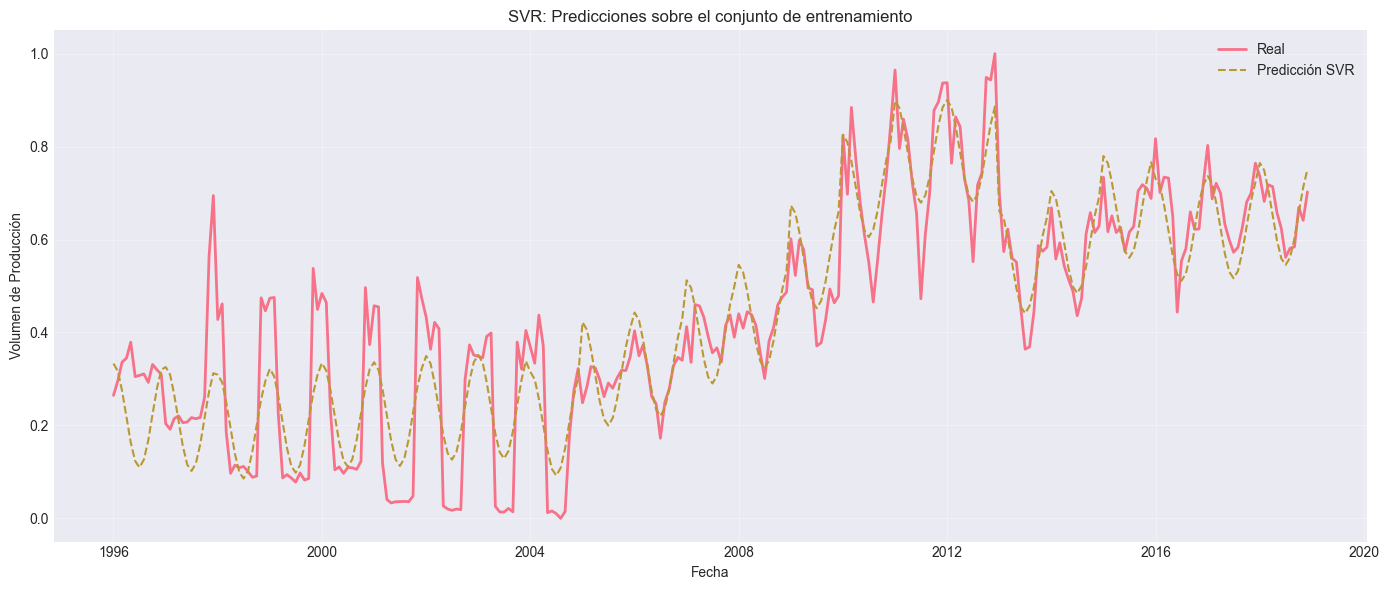

In [39]:
# SVR: Predicciones sobre conjunto de entrenamiento

y_train_pred_svr = svr_model.predict(X_train)

plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train.values, label='Real', linewidth=2)
plt.plot(y_train.index, y_train_pred_svr, label='Predicción SVR', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Volumen de Producción')
plt.title('SVR: Predicciones sobre el conjunto de entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### <a class="anchor" id="5_5">5.5 GPR</a>

**Descripción:** La **Gaussian Process Regression (GPR)** es un enfoque probabilístico no paramétrico que modela la serie como una distribución sobre funciones. A través de una función de covarianza (kernel), GPR captura la estructura de dependencia entre observaciones y genera predicciones junto con estimaciones explícitas de incertidumbre.

##### Selección de Kernel

In [40]:
# Agregar lag1
y_train_lag = y_train.shift(1)
X_train["lag1"] = y_train_lag

# Eliminar primera fila (NaN por lag)
X_train = X_train.iloc[1:]
y_train = y_train.iloc[1:]

# Test
X_test["lag1"] = y_test.shift(1)
X_test.iloc[0, X_test.columns.get_loc("lag1")] = y_train.iloc[-1]

In [41]:
# Definir kernels base
kernels = {
    "Linear": DotProduct(),
    "RBF": RBF(),
    "Matern_1.5": Matern(nu=1.5),
    "Matern_2.5": Matern(nu=2.5),
    "RationalQuadratic": RationalQuadratic()
}

resultados_kernels = []

for nombre, kernel in kernels.items():

    print(f"\nEvaluando kernel: {nombre}")

    # Modelo GPR
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        random_state=42
    )

    # Entrenamiento
    gpr.fit(X_train, y_train)

    # Predicción
    y_pred, y_std = gpr.predict(X_test, return_std=True)

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # MASE respecto a naive ya calculado
    naive_mae = mean_absolute_error(y_test, y_naive)
    mase = mae / naive_mae if naive_mae != 0 else np.inf

    resultados_kernels.append({
        "Kernel": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "MASE": mase
    })

# Crear DataFrame comparativo
df_kernels = pd.DataFrame(resultados_kernels)

# Ranking combinado
df_kernels["Rank_MAE"] = df_kernels["MAE"].rank()
df_kernels["Rank_RMSE"] = df_kernels["RMSE"].rank()
df_kernels["Rank_MAPE"] = df_kernels["MAPE"].rank()
df_kernels["Rank_MASE"] = df_kernels["MASE"].rank()

df_kernels["Rank_Promedio"] = df_kernels[
    ["Rank_MAE", "Rank_RMSE", "Rank_MAPE", "Rank_MASE"]
].mean(axis=1)

df_kernels = df_kernels.sort_values("Rank_Promedio")

df_kernels


Evaluando kernel: Linear

Evaluando kernel: RBF

Evaluando kernel: Matern_1.5

Evaluando kernel: Matern_2.5

Evaluando kernel: RationalQuadratic


,Kernel,MAE,RMSE,MAPE,MASE,Rank_MAE,Rank_RMSE,Rank_MAPE,Rank_MASE,Rank_Promedio
0,Linear,0.053422,0.062723,7.728334,0.597679,1.0,1.0,1.0,1.0,1.0
4,RationalQuadratic,0.055636,0.072146,7.992484,0.622447,2.0,2.0,2.0,2.0,2.0
2,Matern_1.5,0.060974,0.082375,9.515954,0.682172,3.0,3.0,3.0,3.0,3.0
3,Matern_2.5,0.086647,0.111761,12.649680,0.969398,4.0,4.0,4.0,4.0,4.0
1,RBF,0.213929,0.246333,30.243220,2.393417,5.0,5.0,5.0,5.0,5.0


##### Entrenamiento y Predicción

In [42]:
# Definir kernel final
kernel_final = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    (
        Matern(length_scale=1.0, nu=1.5) +
        RationalQuadratic(length_scale=1.0, alpha=1.0)
    ) +
    WhiteKernel(noise_level=1e-5)
)

# Crear modelo
gpr_model = GaussianProcessRegressor(
    kernel=kernel_final,
    n_restarts_optimizer=10,
    random_state=42
)

# Entrenar
tiempo_inicial = time.time()
gpr_model.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - tiempo_inicial

print(f"Tiempo de entrenamiento GPR: {tiempo_entrenamiento:.2f} segundos\n")

# Predicción (media + desviación estándar)
y_pred_gpr, y_std_gpr = gpr_model.predict(X_test, return_std=True)

print("Kernel optimizado:")
print(gpr_model.kernel_)

Tiempo de entrenamiento GPR: 11.46 segundos

Kernel optimizado:
0.888**2 * Matern(length_scale=8.27, nu=1.5) + RationalQuadratic(alpha=0.00192, length_scale=0.811) + WhiteKernel(noise_level=1e-05)


##### Visualizaciones

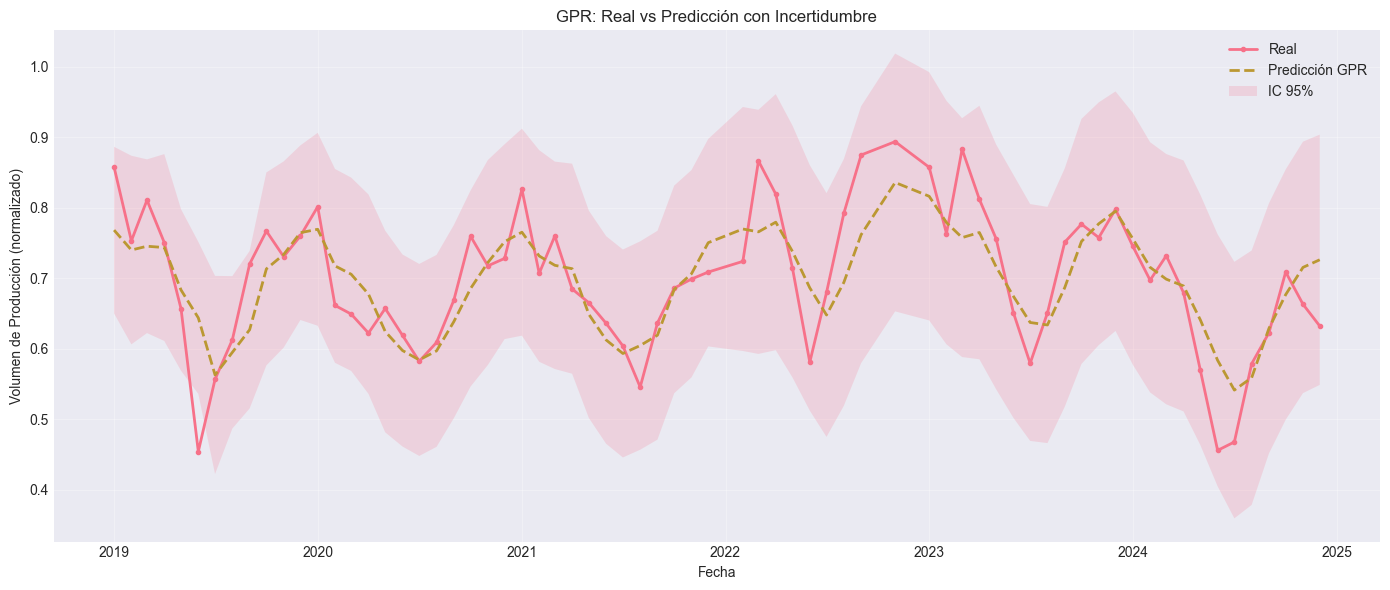

In [43]:
# Intervalos de confianza
lower_bound = y_pred_gpr - 2 * y_std_gpr
upper_bound = y_pred_gpr + 2 * y_std_gpr

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_test.index, y_test.values,
        label='Real', linewidth=2, marker='o', markersize=3)

ax.plot(y_test.index, y_pred_gpr,
        label='Predicción GPR', linewidth=2, linestyle='--')

ax.fill_between(
    y_test.index,
    lower_bound,
    upper_bound,
    alpha=0.2,
    label='IC 95%'
)

ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción (normalizado)')
ax.set_title('GPR: Real vs Predicción con Incertidumbre')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Diagnóstico de Residuos: GPR ---
Media residuos: 0.003745
Varianza residuos: 0.003153

Ljung-Box p-value: 0.09786355055341528


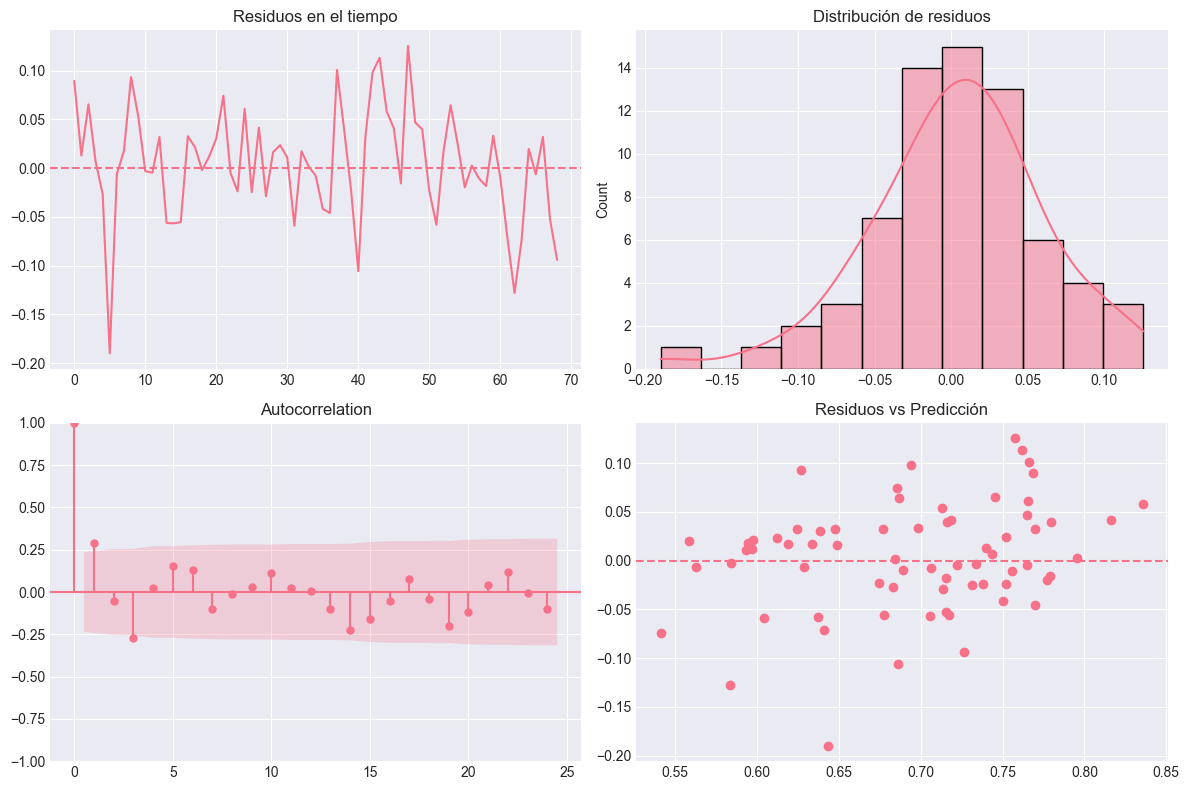

In [44]:
# Diagnóstico de residuos para GPR
residuos_gpr = residuals_diagnostic(y_test, y_pred_gpr, lags=24, titulo="GPR")

##### Métricas Finales

In [45]:
# Calcular métricas
metrics_gpr = calculate_metrics(
    y_true=y_test,
    y_pred=y_pred_gpr,
    mase_denom=mase_denom,
    model_name="GPR"
)
metrics_gpr["Tiempo_Entrenamiento"] = tiempo_entrenamiento

# Guardar resultados
resultados_modelos.append(metrics_gpr)
print(metrics_gpr)

# Almacenar modelo
modelos_entrenados['GPR'] = {
    'modelo': gpr_model,
    'y_pred': y_pred_gpr,
    'y_std': y_std_gpr
}

# Remover "lag1" para no afectar otros modelos
X_train = X_train.drop(columns=["lag1"])
X_test = X_test.drop(columns=["lag1"])

{'Modelo': 'GPR', 'MAE': 0.04277178623225242, 'RMSE': 0.05627992546367392, 'MAPE': 6.41122782046334, 'R²': 0.6767142805947902, 'MASE': 0.49389159670681554, 'Tiempo_Entrenamiento': 11.456007957458496}


#### <a class="anchor" id="5_6">5.6 MLP</a>

**Descripción:** El **Multi-Layer Perceptron (MLP)** es una red neuronal artificial de tipo feedforward compuesta por capas ocultas y funciones de activación no lineales. A través del aprendizaje por retropropagación, el modelo ajusta pesos internos para aproximar relaciones complejas entre entradas y salida.

In [46]:
# Definir modelo inicial
mlp_model_init = MLPRegressor(
                          hidden_layer_sizes=(100,),
                          activation='relu',
                          solver='adam',
                          alpha=0.0001,
                          learning_rate_init=0.001,
                          max_iter=500,
                          random_state=42
                          )

# Entrenamiento
mlp_model_init.fit(X_train, y_train)

# Predicción
y_mlp_init = mlp_model_init.predict(X_test)

In [47]:
# Métricas modelo inicial
metrics_mlp_init = calculate_metrics(
    y_test,
    y_mlp_init,
    mase_denom,
    model_name="MLP"
)


metrics_mlp_init

{'Modelo': 'MLP',
 'MAE': 0.05901316206101375,
 'RMSE': 0.07202385844975911,
 'MAPE': 8.515065667648253,
 'R²': 0.47054109045567916,
 'MASE': 0.6814329586042467}

In [48]:
# Definir modelo cambiado
mlp_model_camb = MLPRegressor(
                          hidden_layer_sizes=(20,10),
                          activation='relu',
                          solver='adam',
                          alpha=0.001,
                          learning_rate_init=0.001,
                          max_iter=500,
                          random_state=42
                          )

# Entrenamiento
mlp_model_camb.fit(X_train, y_train)

# Predicción
y_mlp_camb = mlp_model_camb.predict(X_test)

In [49]:
# Métricas
metrics_mlp_camb = calculate_metrics(
                                    y_test,
                                    y_mlp_camb,
                                    mase_denom,
                                    model_name="MLP"
                                )


metrics_mlp_camb

{'Modelo': 'MLP',
 'MAE': 0.1173119670766871,
 'RMSE': 0.13751997024466123,
 'MAPE': 16.97152759137172,
 'R²': -0.9302387638726961,
 'MASE': 1.3546171398526419}

In [50]:
# Definir modelo
mlp_model = MLPRegressor(
                          hidden_layer_sizes=(100,),
                          activation='relu',
                          solver='adam',
                          alpha=0.0001,
                          learning_rate_init=0.001,
                          max_iter=500,
                          random_state=42
                          )

# Entrenamiento
tiempo_inicial = time.time()
mlp_model.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - tiempo_inicial

print(f"Tiempo de entrenamiento MLP: {tiempo_entrenamiento:.2f} segundos")

# Predicción
y_mlp = mlp_model.predict(X_test)

Tiempo de entrenamiento MLP: 0.06 segundos


In [51]:
# Métricas
metrics_mlp = calculate_metrics(
    y_test,
    y_mlp,
    mase_denom,
    model_name="MLP"
)
metrics_mlp["Tiempo_Entrenamiento"] = tiempo_entrenamiento

# Guardar resultados
resultados_modelos.append(metrics_mlp)

modelos_entrenados['MLP'] = {
    'modelo': mlp_model,
    'y_pred': y_mlp
}

metrics_mlp

{'Modelo': 'MLP',
 'MAE': 0.05901316206101375,
 'RMSE': 0.07202385844975911,
 'MAPE': 8.515065667648253,
 'R²': 0.47054109045567916,
 'MASE': 0.6814329586042467,
 'Tiempo_Entrenamiento': 0.062187910079956055}

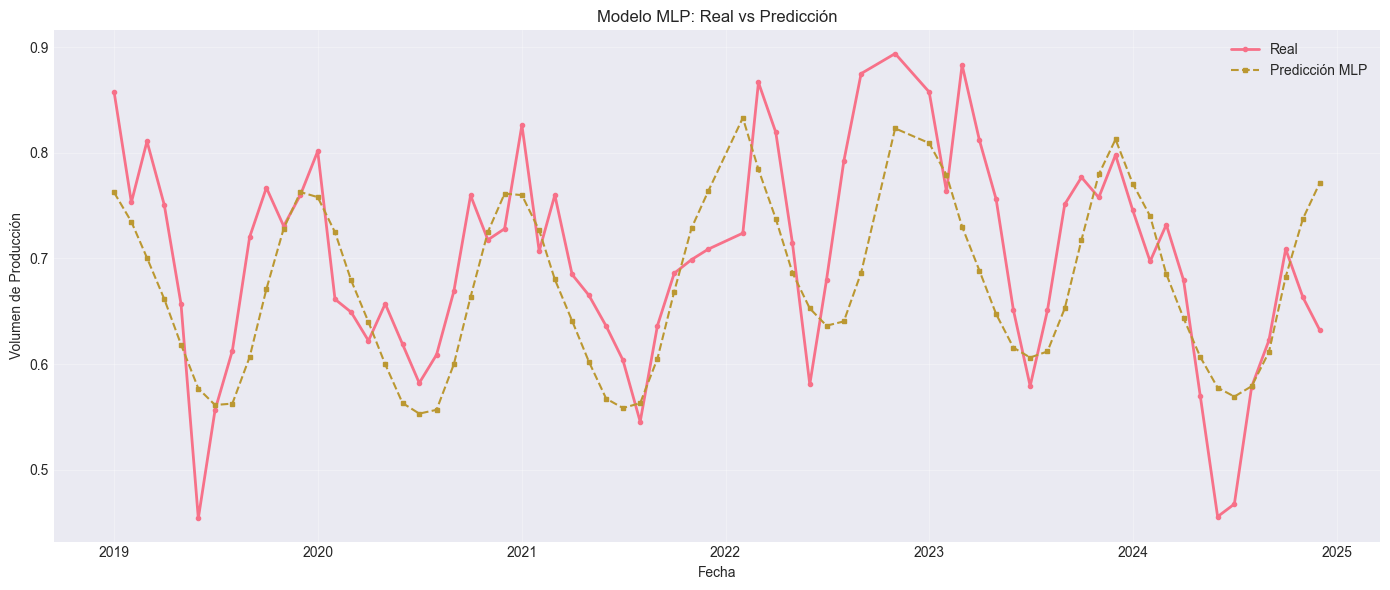

In [52]:
# Visualización: Modelo MLP
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, label='Real', linewidth=2, marker='o', markersize=3)
ax.plot(y_test.index, y_mlp, label='Predicción MLP', linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Fecha')
ax.set_ylabel('Volumen de Producción')
ax.set_title('Modelo MLP: Real vs Predicción')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

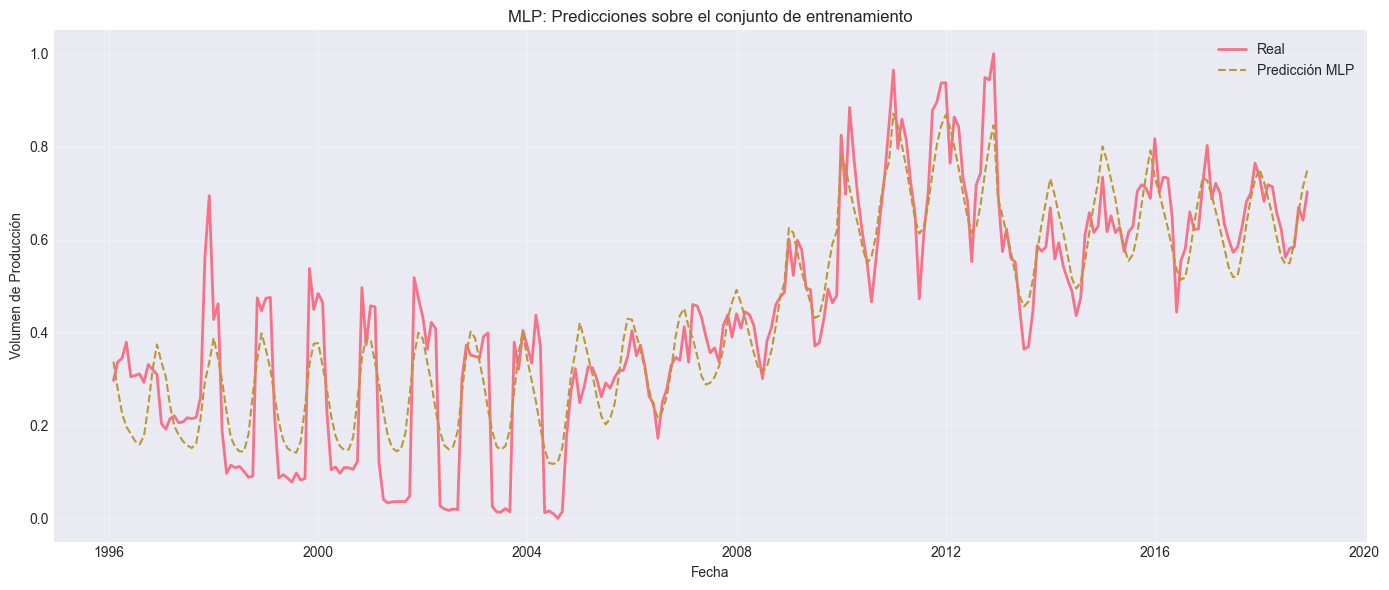

In [53]:
# MLP: Predicciones sobre el conjunto de entrenamiento

y_train_pred_mlp = mlp_model.predict(X_train)

plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train.values, label='Real', linewidth=2)
plt.plot(y_train.index, y_train_pred_mlp, label='Predicción MLP', linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Volumen de Producción')
plt.title('MLP: Predicciones sobre el conjunto de entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### <a class="anchor" id="5_7">5.7 LSTM</a>

**Descripción:** Las **Long Short-Term Memory Networks (LSTM)** son un tipo de red neuronal recurrente diseñada específicamente para modelar dependencias temporales de largo plazo. A diferencia de redes feedforward, las LSTM incorporan celdas de memoria y mecanismos de compuertas que permiten retener o descartar información relevante a lo largo del tiempo.

##### Transformación a estructura secuencial

In [54]:
# Se aplica la transformación log1p para estabilizar la varianza y reducir el efecto
# de la tendencia creciente en la serie, facilitando el aprendizaje de la LSTM.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

train_df = X_train.copy()
train_df['y'] = y_train_log.values

test_df = X_test.copy()
test_df['y'] = y_test_log.values

In [55]:
def create_sequences(data, target_column='y', window=12):
    X_seq = []
    y_seq = []

    for i in range(window, len(data)):
        X_seq.append(data.iloc[i-window:i].values)
        y_seq.append(data.iloc[i][target_column])

    return np.array(X_seq), np.array(y_seq)

In [56]:
window_size = 12

X_train_seq, y_train_seq = create_sequences(train_df, window=window_size)
X_test_seq, y_test_seq = create_sequences(test_df, window=window_size)

print("Shape train:", X_train_seq.shape)
print("Shape test:", X_test_seq.shape)

Shape train: (263, 12, 7)
Shape test: (57, 12, 7)


##### Definición del Modelo

In [57]:
model_lstm = Sequential([
    LSTM(64, input_shape=(window_size, X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss='mse'
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

##### Entrenamiento

In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

tiempo_inicial = time.time()
history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
tiempo_entrenamiento = time.time() - tiempo_inicial

print(f"Tiempo de entrenamiento LSTM: {tiempo_entrenamiento:.2f} segundos")

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0583 - val_loss: 0.0035
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0178 - val_loss: 0.0107
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0137 - val_loss: 0.0020
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0128 - val_loss: 0.0040
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0115 - val_loss: 0.0019
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0070
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0111 - val_loss: 0.0069
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0093 - val_loss: 0.0051
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0083 - val_loss: 0.0093
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0088 - val_loss: 0.0035
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0087 - val_loss: 0.0045
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

##### Predicción

In [59]:
# Predicción
z_pred = model_lstm.predict(X_test_seq).flatten()
y_pred_lstm = np.expm1(z_pred)

# Los primeros 12 puntos de test no se predicen porque no hay secuencia
# completa para esos puntos
y_test_eval = np.expm1(y_test_seq)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


##### Visualización

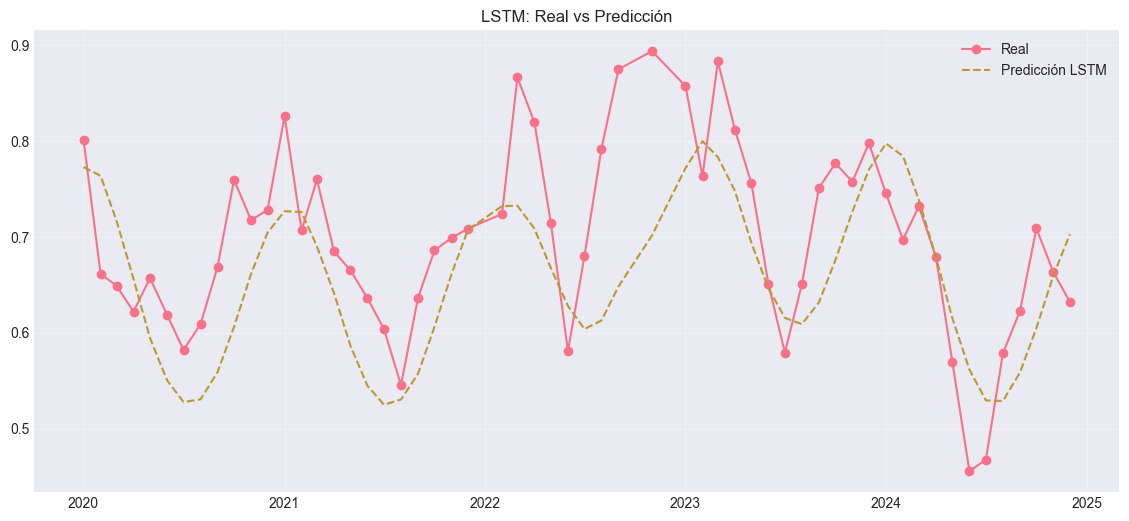

In [60]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(y_test.index[window_size:], y_test_eval,
        label='Real', marker='o')

ax.plot(y_test.index[window_size:], y_pred_lstm,
        label='Predicción LSTM', linestyle='--')

ax.set_title("LSTM: Real vs Predicción")
ax.legend()
ax.grid(alpha=0.3)

plt.show()


--- Diagnóstico de Residuos: LSTM ---
Media residuos: 0.041281
Varianza residuos: 0.005192

Ljung-Box p-value: 0.000103698644903431


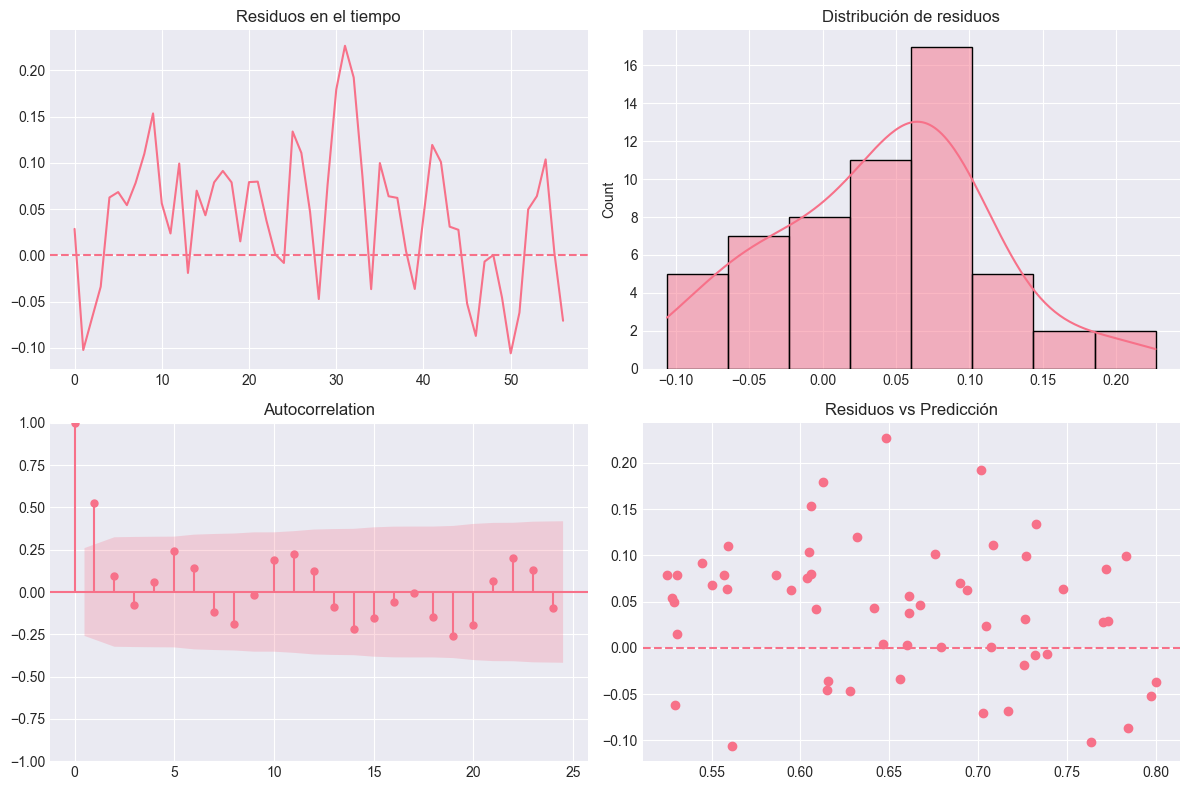

In [61]:
# Diagnóstico de residuos para LSTM
residuos_lstm = residuals_diagnostic(y_test_eval, y_pred_lstm, lags=24, titulo="LSTM")

##### Métricas

In [62]:
metrics_lstm = calculate_metrics(
    y_true=y_test_eval,
    y_pred=y_pred_lstm,
    mase_denom=mase_denom,
    model_name="LSTM"
)
metrics_lstm["Tiempo_Entrenamiento"] = tiempo_entrenamiento

resultados_modelos.append(metrics_lstm)

modelos_entrenados['LSTM'] = {
    'modelo': model_lstm,
    'y_pred': y_pred_lstm
}

print(metrics_lstm)

{'Modelo': 'LSTM', 'MAE': 0.06871810532657276, 'RMSE': 0.08304326345507929, 'MAPE': 9.749712112521781, 'R²': 0.26281022868735715, 'MASE': 0.7934972502227635, 'Tiempo_Entrenamiento': 5.5434911251068115}


### <a class="anchor" id="ensamble">6. Entrenamiento y evaluación de **modelos de ensamble**</a>

XXX

#### <a class="anchor" id="6_1">6.1 Modelo de Ensamble: **Promedio simple (Simple Averaging Ensemble)**</a>

**Ensable de agregación simple (bagging-style aggregation)** basado en **promedio aritmético de predicciones**.

##### Descripción

Este método combina las predicciones de varios modelos base calculando el **promedio simple** de sus resultados. Cada modelo contribuye con el mismo peso a la predicción final, por lo que el ensamble actúa como un mecanismo de **suavizado del error individual de los modelos**.

##### Justificación

El promedio simple es uno de los enfoques más utilizados en ensembles debido a su **simplicidad y robustez**. Incluso cuando algunos modelos presentan errores individuales, el promedio puede reducir la varianza global de las predicciones. Además, sirve como **baseline para evaluar si estrategias de combinación más complejas realmente aportan mejoras**.

##### Modelos base utilizados

* GPR (Gaussian Process Regression)
* SARIMAX
* SVR (Support Vector Regression)
* MLP (Multilayer Perceptron)


##### Entrenamiento y Predicción

In [ ]:
#

##### Visualizaciones

In [ ]:
#

##### Métricas

In [ ]:
#

#### <a class="anchor" id="6_2">6.2 Modelo de Ensamble: **Promedio ponderado (Weighted Average Ensemble)**</a>

**Ensable de agregación ponderada (weighted aggregation ensemble)**.

##### Descripción

Este método extiende el promedio simple asignando **pesos distintos a cada modelo base** según su desempeño individual. Los modelos que presentan menor error reciben mayor peso en la predicción final.

La predicción final se calcula como:

[
\hat{y} = \sum_{i=1}^{n} w_i \hat{y}_i
]

donde (w_i) representa el peso asignado al modelo (i).

##### Justificación

No todos los modelos tienen el mismo nivel de precisión. El promedio ponderado permite **priorizar modelos más confiables**, lo cual puede mejorar la precisión del ensamble en comparación con el promedio simple. Esta técnica es especialmente útil cuando existe **heterogeneidad en el desempeño de los modelos base**.

##### Modelos base utilizados

* GPR
* SARIMAX
* SVR
* MLP


##### Entrenamiento y Predicción

In [ ]:
#

##### Visualizaciones

In [ ]:
#

##### Métricas

In [ ]:
#

#### <a class="anchor" id="6_3">6.3 Modelo de Ensamble: **Apilamiento con meta-modelo lineal (Stacking Ensemble con Ridge Regression)**</a>

**Ensable de apilamiento (stacking ensemble) con meta-modelo lineal**.

##### Descripción

El stacking consiste en entrenar un **meta-modelo** que aprende cómo combinar las predicciones generadas por los modelos base. En este caso, las predicciones de los modelos base se utilizan como variables de entrada para una **regresión Ridge**, la cual produce la predicción final.

La estructura del modelo es:

Modelos base → Predicciones → Meta-modelo (Ridge) → Predicción final

##### Justificación

A diferencia de los métodos de promedio, el stacking permite que el modelo aprenda **cómo combinar las predicciones de manera óptima**. El uso de Ridge Regression como meta-modelo ayuda a controlar la multicolinealidad entre las predicciones de los modelos base y proporciona una combinación estable y regularizada.

##### Modelos base utilizados

* GPR
* SARIMAX
* SVR
* MLP

Meta-modelo:

* Ridge Regression

##### Entrenamiento y Predicción

In [ ]:
#

##### Visualizaciones

In [ ]:
#

##### Métricas

In [ ]:
#

#### <a class="anchor" id="6_4">6.4 Modelo de Ensamble: **Apilamiento con meta-modelo no lineal (Stacking Ensemble con Random Forest)**</a>

**Ensable de apilamiento (stacking ensemble) con meta-modelo basado en árboles**.

##### Descripción

En este enfoque se utiliza un **Random Forest** como meta-modelo para combinar las predicciones generadas por los modelos base. A diferencia del stacking lineal, el Random Forest puede capturar **relaciones no lineales entre las predicciones de los modelos base**.

La estructura es:

Modelos base → Predicciones → Meta-modelo (Random Forest) → Predicción final

##### Justificación

Las relaciones entre las predicciones de diferentes modelos pueden ser complejas y no necesariamente lineales. El uso de Random Forest como meta-modelo permite capturar **interacciones y patrones no lineales** entre los modelos base, lo que puede mejorar el desempeño del ensamble en escenarios donde los errores de los modelos no siguen una estructura lineal simple.

##### Modelos base utilizados

* GPR
* SARIMAX
* SVR
* MLP

Meta-modelo:

* RandomForestRegressor

##### Entrenamiento y Predicción

In [ ]:
#

##### Visualizaciones

In [ ]:
#

##### Métricas

In [ ]:
#

### <a class="anchor" id="comparacion">7. Comparación global de modelos</a>

Se seleccionó **MASE como métrica principal** debido a que es una medida escalable y robusta para problemas de series temporales. MASE compara el error del modelo contra un pronóstico ingenuo (Naïve Temporal), permitiendo interpretar directamente si el modelo mejora el desempeño de una predicción simple. Valores menores a 1 indican que el modelo supera al baseline.

Para comparar los modelos se construyó un ranking basado en un **score ponderado de métricas normalizadas**.

Se asignó mayor peso a **MASE (50%)**, por ser la métrica principal. Métricas adicionales como **RMSE (15%)** y **MAE (15%)** capturan la magnitud del error absoluto y cuadrático, mientras que **MAPE (10%)** y **R² (10%)** aportan información complementaria sobre error relativo y capacidad explicativa del modelo.

Las métricas fueron normalizadas mediante **min-max scaling** para hacerlas comparables antes de calcular el score final.

#### 7.1 Ranking de Modelos

In [63]:
# Convertir a DataFrame
df_metricas = pd.DataFrame(resultados_modelos)

# Copia para trabajar
df_rank = df_metricas.copy()

# Convertir R² a error
df_rank['R2_error'] = 1 - df_rank['R²']

# Métricas a usar
metricas = ['MAE', 'RMSE', 'MAPE', 'MASE', 'R2_error']

# Pesos (MASE dominante)
pesos = {
    'MAE': 0.15,
    'RMSE': 0.15,
    'MAPE': 0.10,
    'MASE': 0.50,
    'R2_error': 0.10
}

# Normalización min-max
for m in metricas:

    min_m = df_rank[m].min()
    max_m = df_rank[m].max()

    if max_m - min_m == 0:
        df_rank[m + '_norm'] = 0
    else:
        df_rank[m + '_norm'] = (df_rank[m] - min_m) / (max_m - min_m)

# Score ponderado
df_rank['Score_final'] = 0

for m in metricas:
    df_rank['Score_final'] += pesos[m] * df_rank[m + '_norm']

# Ordenar ranking
df_rank = df_rank.sort_values('Score_final')

ranking_final = df_rank[['Modelo','Score_final','MASE','RMSE','MAE','MAPE','R²','Tiempo_Entrenamiento']].reset_index(drop=True)

ranking_final

,Modelo,Score_final,MASE,RMSE,MAE,MAPE,R²,Tiempo_Entrenamiento
0,GPR,0.000000,0.493892,0.056280,0.042772,6.411228,0.676714,11.456008
1,SARIMAX,0.136681,0.576657,0.063460,0.049939,7.411434,0.588960,22.384575
2,SVR,0.235922,0.642383,0.067041,0.055631,8.099991,0.541263,0.011528
3,MLP,0.306677,0.681433,0.072024,0.059013,8.515066,0.470541,0.062188
4,LSTM,0.502286,0.793497,0.083043,0.068718,9.749712,0.262810,5.543491
5,Auto-ARIMA,0.812738,0.945814,0.104104,0.081909,12.785917,-0.106143,113.299200
6,Naïve Estacional,0.945841,1.032108,0.110669,0.089382,12.996779,-0.250060,0.002750
7,ARIMA,1.000000,1.063822,0.113730,0.092129,13.198084,-0.320164,113.299200


#### 7.2 Visualización comparativa

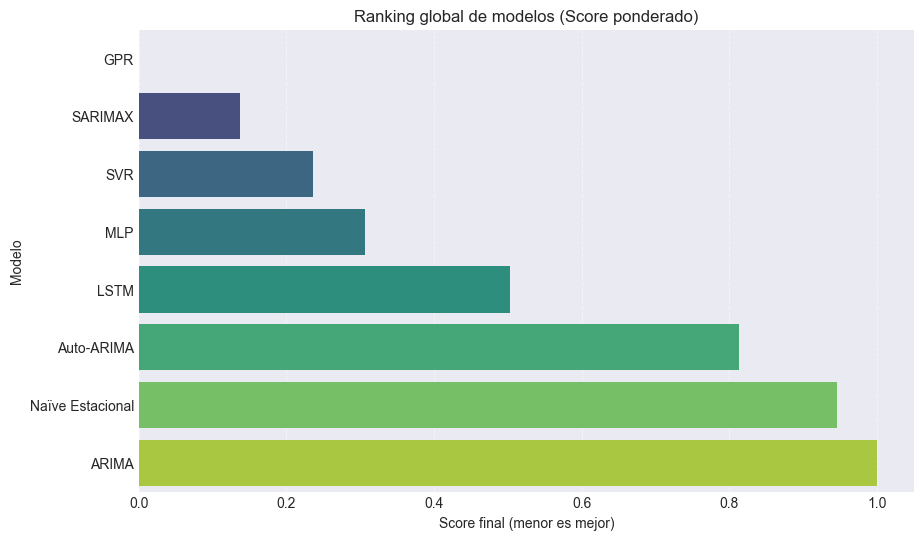

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_rank,
    x='Score_final',
    y='Modelo',
    palette='viridis'
)

plt.title("Ranking global de modelos (Score ponderado)")
plt.xlabel("Score final (menor es mejor)")
plt.ylabel("Modelo")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

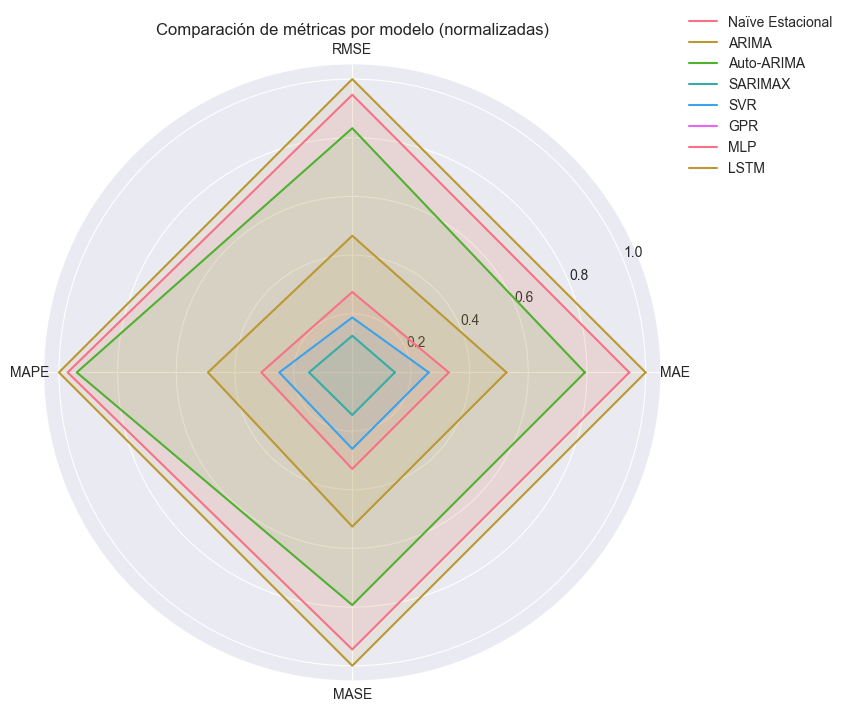

In [65]:
metricas = ['MAE', 'RMSE', 'MAPE', 'MASE']

df_radar = df_metricas.set_index('Modelo')[metricas]

# Normalizar
df_radar = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

labels = metricas
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for modelo in df_radar.index:

    values = df_radar.loc[modelo].values
    values = np.concatenate((values,[values[0]]))

    ax.plot(angles, values, label=modelo)
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(angles[:-1]*180/np.pi, labels)

plt.title("Comparación de métricas por modelo (normalizadas)")
plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.show()

In [66]:
top3 = ranking_final['Modelo'].head(3).tolist()
top3

['GPR', 'SARIMAX', 'SVR']

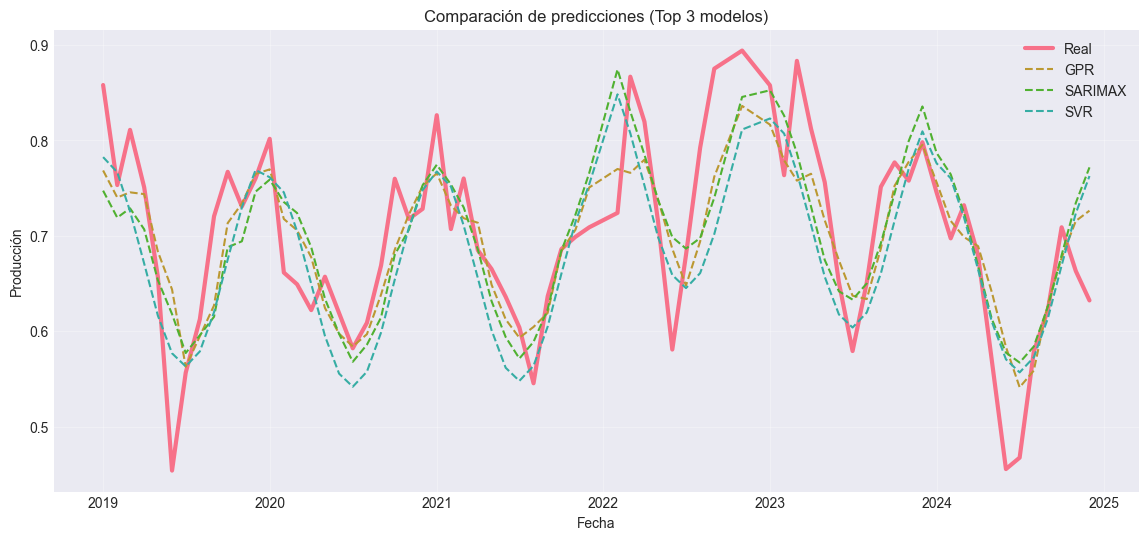

In [67]:
plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test, label='Real', linewidth=3)

for modelo in top3:

    y_pred = modelos_entrenados[modelo]['y_pred']

    plt.plot(
        y_test.index,
        y_pred,
        label=modelo,
        linestyle='--'
    )

plt.title("Comparación de predicciones (Top 3 modelos)")
plt.xlabel("Fecha")
plt.ylabel("Producción")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### 7.3 Selección del modelo final

XXX

In [68]:
# Código en caso de que se necesite soporte para justificar la selección

### <a class="anchor" id="interpretacion">8. Interpretación del modelo final</a>

XXX

##### Visualizaciones



In [ ]:
# Código para crear algunas o todas estas visualizaciones

# Serie temporal: Real vs Predicción Ensemble
# Residuos: residuos vs tiempo
# Distribución de errores: histograma de residuos
# Importancia de modelos (stacking): coeficientes del meta-modelo.
# ACF de residuos: Para ver autocorrelación restante.
# Importancia de modelos (si se usa stacking): Si usas Random Forest como meta-modelo.


### <a class="anchor" id="conclusiones">Conclusiones</a>

xxx

### <a class="anchor" id="ref">Referencias</a>

Agregar referencias